<a href="https://colab.research.google.com/github/dot-eagle/0x00-python-hello_world/blob/master/ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exercise 1 Notebook**

## **Time-related feature engineering**

## **Update and Import libraries**

In [ ]:
!pip install -U scikit-learn

In [ ]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

## **Data exploration on the Bike Sharing Demand dataset**

In [ ]:
# Loading the data from the OpenML repository

bike_sharing = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True)
df = bike_sharing.frame


In [ ]:
df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


 For periodic patterns of the data, let us have a look at the average demand per hour during a week.

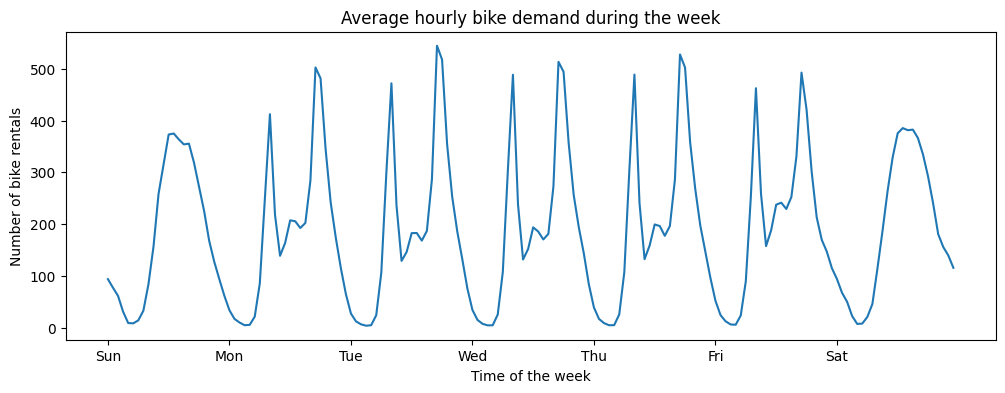

In [ ]:
# For periodic patterns of the data, let us have a look at the average demand per hour during a week.

fig, ax = plt.subplots(figsize=(12, 4))
average_week_demand = df.groupby(["weekday", "hour"])["count"].mean()
average_week_demand.plot(ax=ax)
_ = ax.set(
    title="Average hourly bike demand during the week",
    xticks=[i * 24 for i in range(7)],
    xticklabels=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    xlabel="Time of the week",
    ylabel="Number of bike rentals",
)

The target of the prediction problem is the absolute count of bike rentals on an hourly basis:

In [ ]:
df["count"].max()

977

Let us rescale the target variable (number of hourly bike rentals) to predict a relative demand so that the mean absolute error is more easily interpreted as a fraction of the maximum demand.

In [ ]:
y = df["count"] / df["count"].max()
y

,count
0,0.016377
1,0.040942
2,0.032753
3,0.013306
4,0.001024
...,...
17374,0.121801
17375,0.091095
17376,0.092119
17377,0.062436


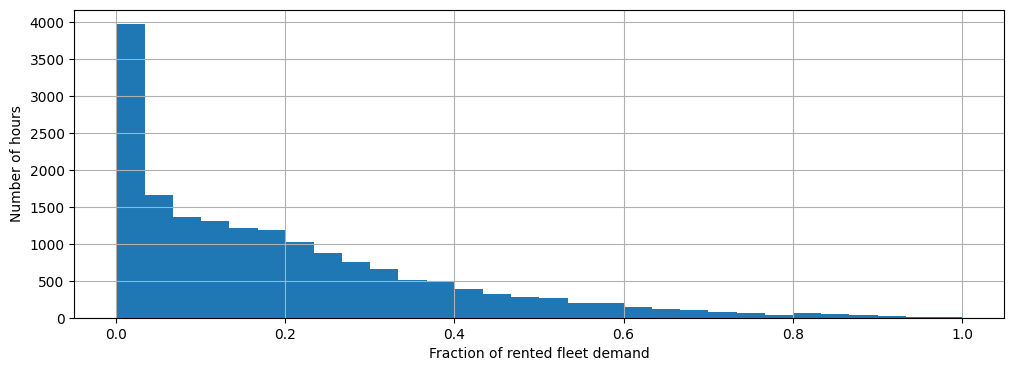

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
y.hist(bins=30, ax=ax)
_ = ax.set(
    xlabel="Fraction of rented fleet demand",
    ylabel="Number of hours",
)


The input feature data frame is a time annotated hourly log of variables describing the weather conditions. It includes both numerical and categorical variables. Note that the time information has already been expanded into several complementary columns.

In [ ]:
X = df.drop("count", axis="columns")
X

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0000
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0000
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0000
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0000
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,spring,1,12,19,False,1,True,misty,10.66,12.880,0.60,11.0014
17375,spring,1,12,20,False,1,True,misty,10.66,12.880,0.60,11.0014
17376,spring,1,12,21,False,1,True,clear,10.66,12.880,0.60,11.0014
17377,spring,1,12,22,False,1,True,clear,10.66,13.635,0.56,8.9981


We now introspect the distribution of the categorical variables, starting with "weather":

In [ ]:
X["weather"].value_counts()

,count
weather,
clear,11413
misty,4544
rain,1419
heavy_rain,3


Since there are only 3 "heavy_rain" events, we cannot use this category to train machine learning models with cross validation. Instead, we simplify the representation by collapsing those into the "rain" category.

In [ ]:
X["weather"] = (
    X["weather"]
    .astype(object)
    .replace(to_replace="heavy_rain", value="rain")
    .astype("category")
)

In [ ]:
X["weather"].value_counts()

,count
weather,
clear,11413
misty,4544
rain,1422


As expected, the "season" variable is well balanced:

In [ ]:
X["season"].value_counts()

,count
season,
fall,4496
summer,4409
spring,4242
winter,4232


## **Time-based cross-validation**

1000 test datapoints should be enough to quantify the performance of the model. This represents a bit less than a month and a half of contiguous test data:

In [ ]:
# from sklearn.model_selection import TimeSeriesSplit

ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=48,
    max_train_size=10000,
    test_size=1000,
)

Let us manually inspect the various splits to check that the TimeSeriesSplit works as we expect, starting with the first split:

In [ ]:
all_splits = list(ts_cv.split(X, y))
train_0, test_0 = all_splits[0]

In [ ]:
X.iloc[test_0]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
12379,summer,1,6,0,False,2,True,clear,22.14,25.760,0.68,27.9993
12380,summer,1,6,1,False,2,True,misty,21.32,25.000,0.77,22.0028
12381,summer,1,6,2,False,2,True,rain,21.32,25.000,0.72,19.9995
12382,summer,1,6,3,False,2,True,rain,20.50,24.240,0.82,12.9980
12383,summer,1,6,4,False,2,True,rain,20.50,24.240,0.82,12.9980
...,...,...,...,...,...,...,...,...,...,...,...,...
13374,fall,1,7,11,False,1,True,clear,34.44,40.150,0.53,15.0013
13375,fall,1,7,12,False,1,True,clear,34.44,39.395,0.49,8.9981
13376,fall,1,7,13,False,1,True,clear,34.44,39.395,0.49,19.0012
13377,fall,1,7,14,False,1,True,clear,36.08,40.910,0.42,7.0015


In [ ]:
X.iloc[train_0]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
2331,summer,0,4,1,False,2,True,misty,25.42,31.060,0.50,6.0032
2332,summer,0,4,2,False,2,True,misty,24.60,31.060,0.53,8.9981
2333,summer,0,4,3,False,2,True,misty,23.78,27.275,0.56,8.9981
2334,summer,0,4,4,False,2,True,misty,22.96,26.515,0.64,8.9981
2335,summer,0,4,5,False,2,True,misty,22.14,25.760,0.68,8.9981
...,...,...,...,...,...,...,...,...,...,...,...,...
12326,summer,1,6,19,False,6,False,clear,26.24,31.060,0.36,11.0014
12327,summer,1,6,20,False,6,False,clear,25.42,31.060,0.35,19.0012
12328,summer,1,6,21,False,6,False,clear,24.60,31.060,0.40,7.0015
12329,summer,1,6,22,False,6,False,clear,23.78,27.275,0.46,8.9981


In [ ]:
# all_splits = list(ts_cv.split(X, y))
train_1, test_1 = all_splits[1]
X.iloc[test_1]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
13379,fall,1,7,16,False,1,True,rain,31.16,36.365,0.66,39.0007
13380,fall,1,7,17,False,1,True,rain,31.16,36.365,0.66,39.0007
13381,fall,1,7,18,False,1,True,clear,34.44,40.150,0.53,0.0000
13382,fall,1,7,19,False,1,True,clear,32.80,39.395,0.63,8.9981
13383,fall,1,7,20,False,1,True,clear,32.80,38.635,0.59,8.9981
...,...,...,...,...,...,...,...,...,...,...,...,...
14374,fall,1,8,3,False,1,True,clear,25.42,28.030,0.88,6.0032
14375,fall,1,8,4,False,1,True,clear,25.42,28.790,0.83,0.0000
14376,fall,1,8,5,False,1,True,clear,25.42,28.030,0.88,0.0000
14377,fall,1,8,6,False,1,True,clear,25.42,28.030,0.88,0.0000


In [ ]:
X.iloc[train_0]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
2331,summer,0,4,1,False,2,True,misty,25.42,31.060,0.50,6.0032
2332,summer,0,4,2,False,2,True,misty,24.60,31.060,0.53,8.9981
2333,summer,0,4,3,False,2,True,misty,23.78,27.275,0.56,8.9981
2334,summer,0,4,4,False,2,True,misty,22.96,26.515,0.64,8.9981
2335,summer,0,4,5,False,2,True,misty,22.14,25.760,0.68,8.9981
...,...,...,...,...,...,...,...,...,...,...,...,...
12326,summer,1,6,19,False,6,False,clear,26.24,31.060,0.36,11.0014
12327,summer,1,6,20,False,6,False,clear,25.42,31.060,0.35,19.0012
12328,summer,1,6,21,False,6,False,clear,24.60,31.060,0.40,7.0015
12329,summer,1,6,22,False,6,False,clear,23.78,27.275,0.46,8.9981


We now inspect the last split:

In [ ]:
train_4, test_4 = all_splits[4]
X.iloc[test_4]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
16379,winter,1,11,5,False,2,True,misty,13.94,16.665,0.66,8.9981
16380,winter,1,11,6,False,2,True,misty,13.94,16.665,0.71,11.0014
16381,winter,1,11,7,False,2,True,clear,13.12,16.665,0.76,6.0032
16382,winter,1,11,8,False,2,True,clear,13.94,16.665,0.71,8.9981
16383,winter,1,11,9,False,2,True,misty,14.76,18.940,0.71,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,spring,1,12,19,False,1,True,misty,10.66,12.880,0.60,11.0014
17375,spring,1,12,20,False,1,True,misty,10.66,12.880,0.60,11.0014
17376,spring,1,12,21,False,1,True,clear,10.66,12.880,0.60,11.0014
17377,spring,1,12,22,False,1,True,clear,10.66,13.635,0.56,8.9981


In [ ]:
X.iloc[train_4]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
6331,winter,0,9,9,False,1,True,misty,26.24,28.790,0.89,12.9980
6332,winter,0,9,10,False,1,True,misty,26.24,28.790,0.89,12.9980
6333,winter,0,9,11,False,1,True,clear,27.88,31.820,0.79,15.0013
6334,winter,0,9,12,False,1,True,misty,27.88,31.820,0.79,11.0014
6335,winter,0,9,13,False,1,True,misty,28.70,33.335,0.74,11.0014
...,...,...,...,...,...,...,...,...,...,...,...,...
16326,winter,1,11,0,False,0,False,misty,12.30,15.150,0.70,11.0014
16327,winter,1,11,1,False,0,False,clear,12.30,14.395,0.70,12.9980
16328,winter,1,11,2,False,0,False,clear,11.48,14.395,0.81,7.0015
16329,winter,1,11,3,False,0,False,misty,12.30,15.150,0.81,11.0014


Let's go ahead to do some predictive modeling!

## **Gradient Boosting**

Gradient Boosting Regression with decision trees is often flexible enough to efficiently handle heterogeneous tabular data with a mix of categorical and numerical features as long as the number of samples is large enough.

We are going to use the modern `HistGradientBoostingRegressor` with native support for categorical features. Therefore, we only need to set `categorical_features="from_dtype"` such that features with categorical dtype are considered categorical features. For reference, we extract the categorical features from the dataframe based on the dtype. The internal trees use a dedicated tree splitting rule for these features.

The numerical variables need no preprocessing and, for the sake of simplicity, we only try the default hyper-parameters for this model:

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

gbrt = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=42)
categorical_columns = X.columns[X.dtypes == "category"]
print("Categorical features:", categorical_columns.tolist())

Categorical features: ['season', 'holiday', 'workingday', 'weather']


Let’s evaluate our gradient boosting model with the mean absolute error of the relative demand averaged across our 5 time-based cross-validation splits:

In [ ]:
import numpy as np

def evaluate(model, X, y, cv, model_prop=None, model_step=None):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_estimator=model_prop is not None,
    )
    if model_prop is not None:
        if model_step is not None:
            values = [
                getattr(m[model_step], model_prop) for m in cv_results["estimator"]
            ]
        else:
            values = [getattr(m, model_prop) for m in cv_results["estimator"]]
        print(f"Mean model.{model_prop} = {np.mean(values)}")
    mae = -cv_results["test_neg_mean_absolute_error"]
    rmse = -cv_results["test_neg_root_mean_squared_error"]
    print(
        f"Mean Absolute Error:     {mae.mean():.3f} +/- {mae.std():.3f}\n"
        f"Root Mean Squared Error: {rmse.mean():.3f} +/- {rmse.std():.3f}"
    )


evaluate(gbrt, X, y, cv=ts_cv, model_prop="n_iter_")

Mean model.n_iter_ = 100.0
Mean Absolute Error:     0.044 +/- 0.003
Root Mean Squared Error: 0.068 +/- 0.005


We see that we set max_iter large enough such that early stopping took place.




This model has an average error around 4 to 5% of the maximum demand. This is quite good for a first trial without any hyper-parameter tuning! We just had to make the categorical variables explicit. Note that the time related features are passed as is, i.e. without processing them. But this is not much of a problem for tree-based models as they can learn a non-monotonic relationship between ordinal input features and the target.

This is not the case for linear regression models as we will see in the following.

## **Naive linear regression**

As usual for linear models, categorical variables need to be one-hot encoded. For consistency, we scale the numerical features to the same 0-1 range using `MinMaxScaler`, although in this case it does not impact the results much because they are already on comparable scales:

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
alphas = np.logspace(-6, 6, 25)
naive_linear_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ("categorical", one_hot_encoder, categorical_columns),
        ],
        remainder=MinMaxScaler(),
    ),
    RidgeCV(alphas=alphas),
)


evaluate(
    naive_linear_pipeline, X, y, cv=ts_cv, model_prop="alpha_", model_step="ridgecv"
)

Mean model.alpha_ = 2.7298221281347037
Mean Absolute Error:     0.142 +/- 0.014
Root Mean Squared Error: 0.184 +/- 0.020


It is affirmative to see that the selected `alpha_` is in our specified range.

## **Time-steps as categories**